# Demo 3: Train, tune, and deploy a machine-learning model

In this demo, Amazon SageMaker manages an end-to-end supervised machine-learning workflow:

**Diabetes regression dataset → train/validation/test split → untuned baseline → SageMaker automatic model tuning → best XGBoost model → real-time endpoint → held-out evaluation**

The notebook first trains one fixed-configuration baseline, then launches four XGBoost training jobs with different hyperparameters. It compares their validation RMSE, deploys the best tuned model, and evaluates it on test examples that were not used during training or tuning.

## Learning goals and responsibilities

By the end of this notebook, you should be able to explain why training, validation, and test data have different roles; how hyperparameter tuning compares multiple training jobs; how a model artifact becomes a hosted endpoint; and which responsibilities belong to us versus SageMaker.

The main components are:

- **The diabetes dataset** contains ten standardised patient measurements and a numeric disease-progression target. It is a teaching dataset, not a clinical model.
- **Amazon S3** stores the training and validation data and the model artefacts produced by training.
- **Amazon SageMaker Training** runs the managed XGBoost container on provisioned compute.
- **A fixed baseline training job** shows how XGBoost performs before tuning.
- **SageMaker Automatic Model Tuning** chooses hyperparameter combinations, launches child training jobs, compares validation RMSE, and identifies the best job.
- **A SageMaker endpoint** hosts the chosen model for real-time inference.
- **An IAM execution role** allows SageMaker training and hosting containers to access the permitted AWS resources and S3 data.
- **A local state file** records generated resource names so later notebook cells and cleanup can find the same AWS resources. It is a convenience for this demo, not an AWS service.

SageMaker manages the training machines, job scheduling, container execution, artefact storage integration, and endpoint infrastructure. We remain responsible for the dataset, split strategy, algorithm, objective metric, hyperparameter search space, evaluation method, cost controls, and cleanup.

## 1. Install the Python dependencies

This notebook uses the AWS SDK (`boto3`) to call SageMaker directly, the SageMaker SDK to locate the managed XGBoost container image, pandas for tabular data, and scikit-learn for splitting and evaluation. Restart the kernel if installation requests it. The setup cell locates this demo directory whether Jupyter starts here or at the repository root.

In [7]:
from pathlib import Path

demo_candidates = [
    Path.cwd(),
    Path.cwd() / "demo3_sagemaker_hpo",
    Path.cwd() / "demo" / "demo3_sagemaker_hpo",
]
DEMO_DIR = next((path.resolve() for path in demo_candidates if (path / "requirements.txt").exists()), None)
if DEMO_DIR is None:
    raise RuntimeError("Open this notebook from its folder or the repository root.")

%pip install -r {DEMO_DIR / "requirements.txt"}


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Deployment prerequisite

From the repository's `demo/` directory, run `./manage_demo.sh --demo 3 --action deploy --bucket YOUR-UNIQUE-BUCKET --profile cits5503`. S3 bucket names are globally unique, so replace the placeholder with a name that is unlikely to be used by another AWS account. Omit `--profile` if you use the default AWS profile.

The command creates the bucket and deploys a CloudFormation stack containing a SageMaker execution role. The notebook reads both resource identifiers from the stack outputs. It uses your configured AWS profile through `boto3`; never paste access keys into a notebook.

In [8]:
REGION = "ap-southeast-2"
STACK_NAME = "cits5503-demo3-role"

## 3. How the infrastructure and training workflow fit together

Demo 3 does **not** use SAM. SAM is useful for the serverless functions and event integrations in Demos 1 and 2, whereas this demo creates SageMaker training and hosting resources through API calls. The management script uses the AWS CLI to create the S3 bucket and ordinary CloudFormation to create the IAM execution role declared in [`sagemaker-execution-role.yaml`](sagemaker-execution-role.yaml).

The role's trust policy allows the SageMaker service to assume it:

```yaml
SageMakerExecutionRole:
  Type: AWS::IAM::Role
  Properties:
    AssumeRolePolicyDocument:
      Statement:
        - Principal:
            Service: sagemaker.amazonaws.com
          Action: sts:AssumeRole
```

The template also grants access to objects under the demo's S3 prefix. When this notebook creates a training or endpoint resource, SageMaker assumes the role to read inputs and write model artefacts. The notebook itself uses the current user's AWS credentials to make the SageMaker control-plane API calls.

### Training, selection, and evaluation flow

```mermaid
flowchart LR
    A[Diabetes regression dataset] --> B[Reproducible split]
    B --> C[Training set 60%]
    B --> D[Validation set 20%]
    B --> E[Test set 20%]
    C --> F[Untuned baseline job]
    C --> G[SageMaker tuning job]
    D --> F
    D --> G
    G --> H[Four tuned training jobs]
    F --> I[Compare validation RMSE]
    H --> I
    I -->|Lowest validation RMSE| J[Best tuned model artefact]
    J --> K[SageMaker real-time endpoint]
    E -->|Used only after selection| K
    K --> L[Predictions and test RMSE]
```

The validation set is used both to measure the fixed baseline and to select tuned hyperparameters. The test set remains separate until after model selection; otherwise, the reported test RMSE would be biased by choices made using that same data.

### Imports and Global Definitions

In [9]:
import json
import warnings
from datetime import datetime, timedelta, timezone
from zoneinfo import ZoneInfo

import boto3
import matplotlib.pyplot as plt
import pandas as pd
from botocore.exceptions import ClientError
from IPython.display import Markdown, display
from sagemaker.core import image_uris
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# State persists AWS resource names between cells and across kernel restarts.
STATE_PATH = DEMO_DIR / ".demo-state.json"
GENERATED_DIR = DEMO_DIR / ".generated"
PREFIX = "cits5503/sagemaker-diabetes-hpo"
XGBOOST_VERSION = "1.7-1"
DISPLAY_TIME_ZONE = ZoneInfo("Australia/Perth")

### Helpers for state and AWS sessions

The local state file connects asynchronous notebook stages. These small helpers keep reading, saving, and AWS session creation consistent.

In [10]:
def load_state():
    if not STATE_PATH.exists():
        raise RuntimeError("No state file found. Run the prepare cell first.")
    return json.loads(STATE_PATH.read_text())

def save_state(state):
    STATE_PATH.write_text(json.dumps(state, indent=2) + "\n")

def session_for(state=None):
    return boto3.Session(region_name=(state or {}).get("region", REGION))

# Unique suffixes prevent SageMaker job-name collisions on repeated demonstrations.
def timestamp():
    return datetime.now(timezone.utc).strftime("%y%m%d-%H%M%S")

### Helpers for SageMaker inputs

These helpers locate SageMaker's managed XGBoost image, describe shared training resources, and format the timing table used while HPO runs.

In [11]:
def xgboost_image(region):
    # SageMaker supplies the correct managed XGBoost image URI for each region.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r'Field \"model_', category=UserWarning)
        return image_uris.retrieve("xgboost", region, version=XGBOOST_VERSION)

def input_channel(name, uri):
    # A channel tells the training container where and how to read one dataset.
    return {
        "ChannelName": name, "ContentType": "text/csv", "InputMode": "File",
        "DataSource": {"S3DataSource": {
            "S3DataType": "S3Prefix", "S3Uri": uri,
            "S3DataDistributionType": "FullyReplicated",
        }},
    }

def training_resources(state, instance_type):
    """Configuration shared by baseline training and every HPO trial."""
    return {
        "AlgorithmSpecification": {"TrainingImage": state["image_uri"], "TrainingInputMode": "File"},
        "RoleArn": state["role_arn"],
        "InputDataConfig": [
            input_channel("train", state["s3_uris"]["train"]),
            input_channel("validation", state["s3_uris"]["validation"]),
        ],
        "OutputDataConfig": {"S3OutputPath": f"s3://{state['bucket']}/{state['prefix']}/output"},
        "ResourceConfig": {"InstanceType": instance_type, "InstanceCount": 1, "VolumeSizeInGB": 30},
        "StoppingCondition": {"MaxRuntimeInSeconds": 1800},
    }

def duration_text(seconds):
    hours, remainder = divmod(max(0, int(seconds)), 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

def timing_columns(detail, current_time, typical_duration):
    start, end = detail.get("TrainingStartTime"), detail.get("TrainingEndTime")
    if not start:
        return "Not started", "Pending estimate"
    elapsed = duration_text(((end or current_time) - start).total_seconds())
    if end:
        return elapsed, f"{end.astimezone(DISPLAY_TIME_ZONE):%H:%M:%S AWST} (actual)"
    if typical_duration is None:
        return elapsed, "Pending estimate"
    finish = start + timedelta(seconds=typical_duration)
    return elapsed, f"~{finish.astimezone(DISPLAY_TIME_ZONE):%H:%M:%S AWST}"

### Confirm the pre-provisioned S3 bucket

Before creating jobs, read the bucket and execution role from the deployment stack, then verify that the bucket is accessible. This keeps environment-specific values out of the notebook and catches missing permissions early. The notebook refuses to overwrite an existing `.demo-state.json`, which helps avoid losing track of resources from an earlier run.

In [ ]:
if STATE_PATH.exists():
    raise RuntimeError(f"{STATE_PATH} already exists. Clean up that run before preparing another.")

session = session_for()
cloudformation = session.client("cloudformation")
stack = cloudformation.describe_stacks(StackName=STACK_NAME)["Stacks"][0]
outputs = {item["OutputKey"]: item["OutputValue"] for item in stack.get("Outputs", [])}
parameters = {item["ParameterKey"]: item["ParameterValue"] for item in stack.get("Parameters", [])}

# Older deployments did not expose BucketName as an output, so fall back to the stack parameter.
BUCKET = outputs.get("BucketName", parameters.get("BucketName"))
ROLE_ARN = outputs["RoleArn"]
if not BUCKET:
    raise RuntimeError(f"Stack {STACK_NAME} does not contain a BucketName output or parameter.")

s3 = session.client("s3")
try:
    s3.head_bucket(Bucket=BUCKET)
except ClientError as error:
    raise RuntimeError("Bucket is missing or inaccessible. Run manage_demo.sh --demo 3 --action deploy first.") from error
print(f"Using bucket: {BUCKET}")
print(f"Using SageMaker role: {ROLE_ARN}")

[09/13/26 17:29:24] INFO     Found credentials in environment variables.                        ]8;id=643314;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=678525;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Using bucket: cits5503-demo-bucket
Using SageMaker role: arn:aws:iam::489389878001:role/cits5503-demo3-role-SageMakerExecutionRole-AbQsPZSi0VgS


## 4. Prepare the data

Load scikit-learn's 442-patient diabetes dataset, inspect what it contains, then divide it into training, validation, and test data. SageMaker's built-in XGBoost algorithm expects headerless CSV with the numeric target in the first column.

### Understand the features and prediction target

Each row represents one patient. The ten input features—age, sex, body mass index, average blood pressure, and six blood-serum measurements—were recorded at the baseline visit. They have been centred and scaled, so their stored values are not the original clinical measurements.

The **target** is a numeric measure of disease progression observed one year later. Higher values mean more progression within this dataset. The source does not define a clinical unit, threshold, or conversion: a target of `200` is 190 dataset-score points higher than `10`, but it does **not** mean 20 times the progression or 190 units of a named medical measurement. Treat the values as a relative outcome scale for comparing predictions. The modelling task is to predict this one-year score from the baseline features.

**Dataset source and further reading:** [scikit-learn's diabetes dataset documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset). The documented reference is Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004), [*Least Angle Regression*](https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf), *The Annals of Statistics*, 32(2), 407–499.

In [13]:
diabetes = load_diabetes(as_frame=True)
data = diabetes.data.copy()
data.insert(0, "target", diabetes.target.astype(float))  # SageMaker XGBoost expects the target first.

feature_meanings = pd.DataFrame({
    "CSV column": diabetes.feature_names,
    "Meaning": [
        "Age", "Sex", "Body mass index", "Average blood pressure",
        "Total serum cholesterol", "Low-density lipoproteins (LDL)",
        "High-density lipoproteins (HDL)", "Total cholesterol / HDL",
        "Log serum triglycerides", "Blood glucose",
    ],
    "Stored as": "Centred and scaled numeric value",
})
display(feature_meanings)

,CSV column,Meaning,Stored as
0,age,Age,Centred and scaled numeric value
1,sex,Sex,Centred and scaled numeric value
2,bmi,Body mass index,Centred and scaled numeric value
3,bp,Average blood pressure,Centred and scaled numeric value
4,s1,Total serum cholesterol,Centred and scaled numeric value
5,s2,Low-density lipoproteins (LDL),Centred and scaled numeric value
6,s3,High-density lipoproteins (HDL),Centred and scaled numeric value
7,s4,Total cholesterol / HDL,Centred and scaled numeric value
8,s5,Log serum triglycerides,Centred and scaled numeric value
9,s6,Blood glucose,Centred and scaled numeric value


### Inspect example patients and the target distribution

The first table shows selected columns for eight patients. The summary beneath shows the range and spread of the target, giving later RMSE values a useful scale.

In [14]:
preview_names = {name: meaning for name, meaning in zip(feature_meanings["CSV column"], feature_meanings["Meaning"])}
preview_names["target"] = "Disease progression target"
preview_columns = ["target", "age", "sex", "bmi", "bp", "s5", "s6"]
display(data[preview_columns].rename(columns=preview_names).head(8).round(3))

,Disease progression target,Age,Sex,Body mass index,Average blood pressure,Log serum triglycerides,Blood glucose
0,151.0,0.038,0.051,0.062,0.022,0.020,-0.018
1,75.0,-0.002,-0.045,-0.051,-0.026,-0.068,-0.092
2,141.0,0.085,0.051,0.044,-0.006,0.003,-0.026
3,206.0,-0.089,-0.045,-0.012,-0.037,0.023,-0.009
4,135.0,0.005,-0.045,-0.036,0.022,-0.032,-0.047
5,97.0,-0.093,-0.045,-0.041,-0.019,-0.041,-0.096
6,138.0,-0.045,0.051,-0.047,-0.016,-0.063,-0.038
7,63.0,0.064,0.051,-0.002,0.067,-0.036,0.003


In [15]:
target_summary = pd.DataFrame({
    "Statistic": ["Minimum", "Median", "Mean", "Maximum", "Standard deviation"],
    "Disease progression target": [
        data["target"].min(), data["target"].median(), data["target"].mean(),
        data["target"].max(), data["target"].std(),
    ],
})
display(target_summary.round(1))

,Statistic,Disease progression target
0,Minimum,25.0
1,Median,140.5
2,Mean,152.1
3,Maximum,346.0
4,Standard deviation,77.1


### Split the dataset by purpose

Use 60% of the rows for fitting models, 20% for comparing the baseline and HPO trials, and hold back 20% for final evaluation. `random_state=42` makes the split reproducible.

In [16]:
# Fixing the random seed makes the classroom results reproducible.
train_validation, test = train_test_split(data, test_size=0.20, random_state=42)
# 25% of the remaining 80% gives 20% validation: a final 60/20/20 split.
train, validation = train_test_split(train_validation, test_size=0.25, random_state=42)

display(pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Rows": [len(train), len(validation), len(test)],
    "Purpose": ["Fit model parameters", "Compare baseline and HPO trials", "Final unbiased evaluation"],
}))

,Split,Rows,Purpose
0,Training,264,Fit model parameters
1,Validation,89,Compare baseline and HPO trials
2,Test,89,Final unbiased evaluation


### Upload each split and save the resource names for later cells

Write the splits as headerless CSV files and upload them under one S3 prefix. Only the training and validation files are given to the training jobs; the test data remains held back until final evaluation. `.demo-state.json` records the resource names needed by later cells.

In [17]:
GENERATED_DIR.mkdir(exist_ok=True)
s3_uris, local_files = {}, {}
for split_name, split_data in {"train": train, "validation": validation, "test": test}.items():
    local_path = GENERATED_DIR / f"{split_name}.csv"
    # Built-in XGBoost expects headerless CSV with the target in column zero.
    split_data.to_csv(local_path, header=False, index=False)
    key = f"{PREFIX}/data/{split_name}.csv"
    s3.upload_file(str(local_path), BUCKET, key)
    s3_uris[split_name] = f"s3://{BUCKET}/{key}"
    local_files[split_name] = str(local_path)
    print(f"Uploaded {split_name:10s} rows={len(split_data):2d}")

state = {
    "region": REGION, "bucket": BUCKET, "prefix": PREFIX, "role_arn": ROLE_ARN,
    "image_uri": xgboost_image(REGION), "s3_uris": s3_uris,
    "local_files": local_files,
    "prepared_at": datetime.now(timezone.utc).isoformat(),
}
save_state(state)
print(f"Saved state to {STATE_PATH}; the test split is held back from tuning.")

Uploaded train      rows=264
Uploaded validation rows=89
Uploaded test       rows=89


[09/13/26 17:29:26] INFO     Ignoring unnecessary instance type: None.                            ]8;id=923024;file:///Users/larryhh/Library/Python/3.11/lib/python/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=436965;file:///Users/larryhh/Library/Python/3.11/lib/python/site-packages/sagemaker/core/image_uris.py#535\535]8;;\

Saved state to /Users/larryhh/Documents/UWA/CITS5503/demo/demo3_sagemaker_hpo/.demo-state.json; the test split is held back from tuning.


## 5. Train an untuned baseline

**XGBoost** (short for *Extreme Gradient Boosting*) is a supervised-learning method that combines many small decision trees into one prediction. It builds the trees in sequence: each new tree learns to reduce errors made by the earlier trees, and their predictions are combined. In this regression task, the final model predicts a numerical disease-progression score. For a deeper explanation, see the [official XGBoost introduction to boosted trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html).

Before tuning, train one model with XGBoost's ordinary defaults: `eta=0.3`, `max_depth=6`, `min_child_weight=1`, and `subsample=1`. This is a genuine first attempt rather than an intentionally weakened model. It uses the same data, 50 boosting rounds, instance type, and validation metric as the later tuning jobs.

Root mean squared error (RMSE) is defined as

$$
\operatorname{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

Here, $y_i$ is the observed disease-progression target, $\hat{y}_i$ is the model's prediction, and $n$ is the number of validation patients. Squaring prevents positive and negative errors from cancelling and gives large misses extra weight; the square root returns the result to target-score points. An RMSE of 52 does not mean every prediction misses by 52 points—it describes the overall error scale, with large errors contributing disproportionately. Lower is better.

To make RMSE interpretable, the cells compare XGBoost with a trivial model that predicts the training-set mean for every validation patient, and report RMSE relative to the validation target's standard deviation. The test set is not used here.

In [18]:
state = load_state()
TRAINING_INSTANCE_TYPE = "ml.m5.large"
sm = session_for(state).client("sagemaker")
baseline_job_name = state.get("baseline_training_job_name")

# Recording the name makes this cell idempotent: rerunning it will not create a second job.
if not baseline_job_name:
    baseline_job_name = f"cits5503-diabetes-baseline-{timestamp()}"
    sm.create_training_job(
        TrainingJobName=baseline_job_name,
        HyperParameters={
            "objective": "reg:squarederror", "eval_metric": "rmse", "num_round": "50",
            "eta": "0.3", "max_depth": "6", "min_child_weight": "1", "subsample": "1",
        },
        **training_resources(state, TRAINING_INSTANCE_TYPE),
    )
    state.update({"baseline_training_job_name": baseline_job_name, "training_instance_type": TRAINING_INSTANCE_TYPE})
    save_state(state)
    print(f"Started baseline training job: {baseline_job_name}")

                    INFO     Found credentials in environment variables.                        ]8;id=501815;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=90823;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Started baseline training job: cits5503-diabetes-baseline-260913-092926


### Wait for the baseline result

Training runs on a managed instance. This cell waits for completion, extracts `validation:rmse`, and saves the resulting model artefact.

In [19]:
state = load_state()
sm = session_for(state).client("sagemaker")
baseline_job_name = state["baseline_training_job_name"]

# create_training_job returns immediately; the waiter blocks until AWS finishes it.
print("Waiting for the baseline training job to finish...")
sm.get_waiter("training_job_completed_or_stopped").wait(TrainingJobName=baseline_job_name)

baseline = sm.describe_training_job(TrainingJobName=baseline_job_name)
if baseline["TrainingJobStatus"] != "Completed":
    raise RuntimeError(f"Baseline training ended with status {baseline['TrainingJobStatus']}")

baseline_metrics = {metric["MetricName"]: metric["Value"] for metric in baseline.get("FinalMetricDataList", [])}
baseline_rmse = baseline_metrics.get("validation:rmse")

if baseline_rmse is None:
    raise RuntimeError(f"SageMaker did not report validation:rmse. Metrics: {baseline_metrics}")
state.update({
    "baseline_validation_rmse": baseline_rmse,
    "baseline_model_artifact": baseline["ModelArtifacts"]["S3ModelArtifacts"],
})
save_state(state)

[09/13/26 17:29:27] INFO     Found credentials in environment variables.                        ]8;id=69941;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=947374;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Waiting for the baseline training job to finish...


### Put the baseline RMSE in context

Read the result in the target's own units first, then compare it with a simple mean-only benchmark and the spread of the validation scores. RMSE is not a percentage or an accuracy score: lower is better, zero is perfect, and large prediction misses receive extra weight.

In [20]:
state = load_state()
baseline_rmse = state["baseline_validation_rmse"]
training_targets = pd.read_csv(state["local_files"]["train"], header=None, usecols=[0]).iloc[:, 0]
validation_targets = pd.read_csv(state["local_files"]["validation"], header=None, usecols=[0]).iloc[:, 0]

mean_prediction = training_targets.mean()
# This simple benchmark asks whether XGBoost beats predicting one value for everyone.
mean_only_rmse = mean_squared_error(validation_targets, [mean_prediction] * len(validation_targets)) ** 0.5
validation_target_sd = validation_targets.std()
error_reduction = mean_only_rmse - baseline_rmse
error_reduction_percent = 100 * error_reduction / mean_only_rmse

In [21]:
display(Markdown(f"""
#### Interpreting the baseline

- Validation scores range from **{validation_targets.min():.0f} to {validation_targets.max():.0f}**, with a standard deviation of **{validation_target_sd:.1f} points**.
- A no-learning model predicts **{mean_prediction:.1f}** for every patient and has an RMSE of **{mean_only_rmse:.1f} points**.
- Untuned XGBoost has an RMSE of **{baseline_rmse:.1f} points**.

The XGBoost errors are therefore on the scale of about **{baseline_rmse:.1f} target-score points**. RMSE is not an accuracy percentage, and it gives larger misses more weight.

Its RMSE is **{error_reduction:.1f} points ({error_reduction_percent:.1f}%) lower** than the no-learning benchmark, so the patient features contain useful predictive information. However, the remaining error is still **{baseline_rmse / validation_target_sd:.0%} of the validation scores' standard deviation**, so this baseline model is far from precise.
"""))


#### Interpreting the baseline

- Validation scores range from **39 to 317**, with a standard deviation of **74.4 points**.
- A no-learning model predicts **149.8** for every patient and has an RMSE of **75.6 points**.
- Untuned XGBoost has an RMSE of **63.2 points**.

The XGBoost errors are therefore on the scale of about **63.2 target-score points**. RMSE is not an accuracy percentage, and it gives larger misses more weight.

Its RMSE is **12.4 points (16.5%) lower** than the no-learning benchmark, so the patient features contain useful predictive information. However, the remaining error is still **85% of the validation scores' standard deviation**, so this baseline model is far from precise.


## 6. Define and start automatic model tuning

A model parameter is learned from data during training; a **hyperparameter** controls how training behaves. Random search now samples four combinations of the following hyperparameters, with at most two jobs running in parallel:

- **`eta` (learning rate, 0.03–0.30):** controls how much each new tree changes the model. A smaller value makes learning more cautious and often needs more boosting rounds; a larger value learns faster but can overshoot or overfit.
- **`subsample` (0.60–1.00):** sets the fraction of training rows randomly used to build each tree. Lower values add randomness that can reduce overfitting, while `1.0` uses every row for every tree.
- **`min_child_weight` (1–10):** sets the minimum total observation weight required in a child node before XGBoost allows a split. Higher values make splitting more conservative and produce simpler trees; lower values allow the model to learn patterns from smaller groups of observations.
- **`max_depth` (2–8):** limits how deep each tree can grow. Deeper trees can model more complex interactions but are more likely to overfit; shallower trees are simpler and more regularized.

Every job uses the same 50-round budget as the baseline, and SageMaker selects the combination with the lowest `validation:rmse`.

Creating the tuning job is asynchronous: this cell returns after SageMaker accepts the request. Run it only once for a prepared state file.

In [22]:
state = load_state()
if state.get("tuning_job_name"):
    raise RuntimeError("A tuning job is already recorded. Use the status cell instead.")

# 4 trials for short demo. At most 2 consume instances simultaneously.
MAX_JOBS = 4
MAX_PARALLEL_JOBS = 2
TRAINING_INSTANCE_TYPE = state["training_instance_type"]

job_name = f"cits5503-dia-{timestamp()}"  # Tuning-job names are limited to 32 characters.

tuning_config = {
    # Random search samples combinations from the ranges below.
    "Strategy": "Random",
    "HyperParameterTuningJobObjective": {"Type": "Minimize", "MetricName": "validation:rmse"},
    "ResourceLimits": {"MaxNumberOfTrainingJobs": MAX_JOBS, "MaxParallelTrainingJobs": MAX_PARALLEL_JOBS},
    "ParameterRanges": {
        "ContinuousParameterRanges": [
            {"Name": "eta", "MinValue": "0.03", "MaxValue": "0.30", "ScalingType": "Linear"},
            {"Name": "subsample", "MinValue": "0.60", "MaxValue": "1.00", "ScalingType": "Linear"},
            {"Name": "min_child_weight", "MinValue": "1", "MaxValue": "10", "ScalingType": "Linear"},
        ],
        "IntegerParameterRanges": [{"Name": "max_depth", "MinValue": "2", "MaxValue": "8", "ScalingType": "Linear"}],
    },
    "TrainingJobEarlyStoppingType": "Off", "RandomSeed": 42,
}

### Define what every HPO trial shares

The objective, data, compute, and 50-round budget stay fixed. Only the four parameter ranges above vary between trials.

In [23]:
training_definition = {
    "StaticHyperParameters": {"objective": "reg:squarederror", "num_round": "50", "eval_metric": "rmse"},
    **training_resources(state, TRAINING_INSTANCE_TYPE),
}

### Submit the asynchronous tuning job

This creates one parent tuning job. SageMaker will launch four child training jobs, with no more than two running at once.

In [24]:
sm = session_for(state).client("sagemaker")

# Submission is asynchronous, so later status cells can be rerun while trials execute.
sm.create_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=job_name,
    HyperParameterTuningJobConfig=tuning_config,
    TrainingJobDefinition=training_definition,
)
state.update({"tuning_job_name": job_name, "training_instance_type": TRAINING_INSTANCE_TYPE, "tuning_started_at": datetime.now(timezone.utc).isoformat()})
save_state(state)
print(f"Started tuning job: {job_name} (runs asynchronously).")

[09/13/26 17:33:28] INFO     Found credentials in environment variables.                        ]8;id=631843;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=123872;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Started tuning job: cits5503-dia-260913-093328 (runs asynchronously).


## 7. Compare the baseline with the tuned jobs

Rerun the status and comparison cells below while tuning is running. They report the overall status and list the fixed baseline beside each child job. Once metrics are available, SageMaker identifies the tuned job with the lowest validation RMSE. A second, compact table grounds those RMSE values against the spread of real target scores and against the mean-only benchmark.

The selected job's trained model is stored as an S3 artefact, commonly a compressed `model.tar.gz`. Saving its job name, metric, and artefact URI in the state file connects the training stage to deployment. The same jobs and metrics can also be inspected on the SageMaker **Hyperparameter tuning jobs** page in the AWS console.

In [25]:
state = load_state()
sm = session_for(state).client("sagemaker")
description = sm.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=state["tuning_job_name"])
print(f"Tuning job: {state['tuning_job_name']}")
print(f"Status:     {description['HyperParameterTuningJobStatus']}")
print(f"Counters:   {json.dumps(description.get('TrainingJobStatusCounters', {}))}")

# SageMaker may report a current best trial before the overall tuning job completes.
best = description.get("BestTrainingJob")
if best:
    best_name = best["TrainingJobName"]
    training = sm.describe_training_job(TrainingJobName=best_name)
    state.update({
        "best_training_job_name": best_name,
        "best_objective_metric": best.get("FinalHyperParameterTuningJobObjectiveMetric"),
        "model_artifact": training["ModelArtifacts"]["S3ModelArtifacts"],
    })
    save_state(state)
    print(f"Best job:   {best_name}")
    print(f"Metric:     {state['best_objective_metric']}")
    print(f"Artifact:   {state['model_artifact']}")

[09/13/26 17:33:29] INFO     Found credentials in environment variables.                        ]8;id=113795;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=593328;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Tuning job: cits5503-dia-260913-093328
Status:     InProgress
Counters:   {"Completed": 0, "InProgress": 0, "RetryableError": 0, "NonRetryableError": 0, "Stopped": 0}


### Compare the individual jobs

**Rerun the cell below to refresh the table while tuning is in progress.** Each run fetches the latest job status from SageMaker and recalculates elapsed time using the current time. Completed jobs show their actual duration; after one HPO trial finishes, its peers use the median completed duration for a rough finish estimate.

The baseline row uses fixed defaults; every HPO row shows the sampled parameters and resulting validation RMSE.

In [32]:
# Refresh all remote and time-dependent values each time this cell runs.
state = load_state()
sm = session_for(state).client("sagemaker")
description = sm.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=state["tuning_job_name"])
best_job_name = description.get("BestTrainingJob", {}).get("TrainingJobName")
jobs = sm.list_training_jobs_for_hyper_parameter_tuning_job(HyperParameterTuningJobName=state["tuning_job_name"], MaxResults=100, SortBy="Name", SortOrder="Ascending").get("TrainingJobSummaries", [])
job_details = {job["TrainingJobName"]: sm.describe_training_job(TrainingJobName=job["TrainingJobName"]) for job in jobs}
now = datetime.now(timezone.utc)

completed_durations = [
    (detail["TrainingEndTime"] - detail["TrainingStartTime"]).total_seconds()
    for detail in job_details.values()
    if detail.get("TrainingStartTime") and detail.get("TrainingEndTime")
]
completed_durations.sort()
# Use the median completed duration as a rough estimate for running trials.
median_duration = completed_durations[len(completed_durations) // 2] if completed_durations else None

baseline_detail = sm.describe_training_job(TrainingJobName=state["baseline_training_job_name"])
baseline_elapsed, baseline_finish = timing_columns(baseline_detail, now, median_duration)

comparison = [{
    "source": "untuned baseline", "best": False,
    "job": state["baseline_training_job_name"], "status": "Completed",
    "validation_rmse": state["baseline_validation_rmse"],
    "time_elapsed": baseline_elapsed, "expected_finish": baseline_finish,
    "eta": "0.3 (default)", "max_depth": "6 (default)",
    "min_child_weight": "1 (default)", "subsample": "1 (default)",
}]

for job in jobs:
    parameters = job.get("TunedHyperParameters", {})
    elapsed, expected_finish = timing_columns(job_details[job["TrainingJobName"]], now, median_duration)
    comparison.append({
        "source": "HPO trial",
        "best": job["TrainingJobName"] == best_job_name,
        "job": job["TrainingJobName"],
        "status": job["TrainingJobStatus"],
        "validation_rmse": job.get("FinalHyperParameterTuningJobObjectiveMetric", {}).get("Value"),
        "time_elapsed": elapsed, "expected_finish": expected_finish,
        "eta": parameters.get("eta"),
        "max_depth": parameters.get("max_depth"),
        "min_child_weight": parameters.get("min_child_weight"),
        "subsample": parameters.get("subsample"),
    })

comparison_df = pd.DataFrame(comparison).sort_values("validation_rmse", na_position="last")
display(comparison_df)

[09/13/26 18:10:12] INFO     Found credentials in environment variables.                        ]8;id=416046;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=991263;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

,source,best,job,status,validation_rmse,time_elapsed,expected_finish,eta,max_depth,min_child_weight,subsample
2,HPO trial,True,cits5503-dia-260913-093328-002-d63ee44b,Completed,54.359612,00:02:08,17:36:28 AWST (actual),0.09760886982828781,2,5.602612479864332,0.8783725449391055
1,HPO trial,False,cits5503-dia-260913-093328-001-e8f89dce,Completed,55.590530,00:02:09,17:36:26 AWST (actual),0.15276928409977047,3,1.6214620678624379,0.9330528129259839
4,HPO trial,False,cits5503-dia-260913-093328-004-976c9075,Completed,57.745220,00:00:48,17:38:26 AWST (actual),0.07502164625184818,7,3.866907188997434,0.6704885226420564
3,HPO trial,False,cits5503-dia-260913-093328-003-ee4fc2c4,Completed,59.070061,00:00:48,17:37:40 AWST (actual),0.212114375306649,3,7.603141763311143,0.6707571342786688
0,untuned baseline,False,cits5503-diabetes-baseline-260913-092926,Completed,63.193409,00:02:09,17:32:16 AWST (actual),0.3 (default),6 (default),1 (default),1 (default)


In [30]:
raise Exception(f"Stop here to avoid running the next cell, which will delete the tuning job and its trials. Rerun the cell above to check the progress of the {MAX_JOBS} HPO trials.")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 raise Exception(f"Stop here to avoid running the next cell, which will delete the tuning     │
│   2                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
Exception: Stop here to avoid running the next cell, which will delete the tuning job and its trials. Rerun the 
cell above to check the progress of the 4 HPO trials.

### Translate the winning RMSE into a meaningful comparison

This final view compares the current best HPO result with untuned XGBoost, the mean-only benchmark, and the spread of the target scores.

In [33]:
# Refresh the tuning result so this cell does not depend on the status cell having run first.
state = load_state()
sm = session_for(state).client("sagemaker")
description = sm.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=state["tuning_job_name"])
best = description.get("BestTrainingJob")

if best and state.get("baseline_validation_rmse"):
    tuned_rmse = best["FinalHyperParameterTuningJobObjectiveMetric"]["Value"]
    training_targets = pd.read_csv(state["local_files"]["train"], header=None, usecols=[0]).iloc[:, 0]
    validation_targets = pd.read_csv(state["local_files"]["validation"], header=None, usecols=[0]).iloc[:, 0]
    target_sd = validation_targets.std()
    mean_prediction = training_targets.mean()
    mean_only_rmse = mean_squared_error(validation_targets, [mean_prediction] * len(validation_targets)) ** 0.5
    baseline_rmse = state["baseline_validation_rmse"]
    improvement = 100 * (state["baseline_validation_rmse"] - tuned_rmse) / state["baseline_validation_rmse"]
    context = pd.DataFrame([
        {"Model": "Predict training mean for everyone", "Validation RMSE": mean_only_rmse},
        {"Model": "Untuned XGBoost", "Validation RMSE": baseline_rmse},
        {"Model": "Best HPO trial", "Validation RMSE": tuned_rmse},
    ])
    context["RMSE as % of target SD"] = 100 * context["Validation RMSE"] / target_sd
    context["Reduction vs mean-only"] = 100 * (mean_only_rmse - context["Validation RMSE"]) / mean_only_rmse
    display(context.style.format({
        "Validation RMSE": "{:.1f}", "RMSE as % of target SD": "{:.0f}%",
        "Reduction vs mean-only": "{:.1f}%",
    }))
    display(Markdown(f"""
The validation targets span **{validation_targets.min():.0f}–{validation_targets.max():.0f} points**, with a standard deviation of **{target_sd:.1f}**. The selected HPO trial lowered RMSE by **{baseline_rmse - tuned_rmse:.1f} target-score points**, a **{improvement:.1f}% reduction** from untuned XGBoost.
"""))
else:
    status = description["HyperParameterTuningJobStatus"]
    counters = description.get("TrainingJobStatusCounters", {})
    display(Markdown(
        f"No HPO trial with a validation RMSE is available yet (tuning status: **{status}**). "
        f"Trial counts: `{json.dumps(counters)}`. Rerun this cell after a trial completes."
    ))

[09/13/26 18:10:27] INFO     Found credentials in environment variables.                        ]8;id=929229;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=293381;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

,Model,Validation RMSE,RMSE as % of target SD,Reduction vs mean-only
0,Predict training mean for everyone,75.6,102%,0.0%
1,Untuned XGBoost,63.2,85%,16.5%
2,Best HPO trial,54.4,73%,28.1%



The validation targets span **39–317 points**, with a standard deviation of **74.4**. The selected HPO trial lowered RMSE by **8.8 target-score points**, a **14.0% reduction** from untuned XGBoost.


### Visualise what the search gained

Each bar is one modelling choice evaluated on the same validation data. Shorter bars are better. The dashed line marks one standard deviation of the validation targets, providing a common scale for the errors.

[09/13/26 18:10:30] INFO     Found credentials in environment variables.                        ]8;id=899979;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=21589;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

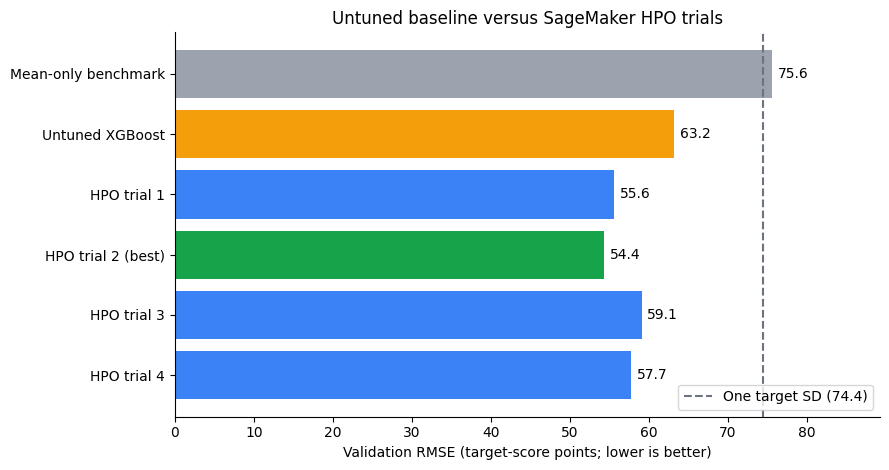

In [34]:
# Refresh the data needed by this chart so it can run independently.
state = load_state()
sm = session_for(state).client("sagemaker")
description = sm.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=state["tuning_job_name"])
best = description.get("BestTrainingJob")

if not best:
    print("A chart will be available after at least one HPO trial reports an RMSE.")
else:
    jobs = sm.list_training_jobs_for_hyper_parameter_tuning_job(
        HyperParameterTuningJobName=state["tuning_job_name"], MaxResults=100,
    ).get("TrainingJobSummaries", [])
    best_job_name = best["TrainingJobName"]
    hpo_rows = pd.DataFrame([{
        "job": job["TrainingJobName"],
        "best": job["TrainingJobName"] == best_job_name,
        "validation_rmse": job.get("FinalHyperParameterTuningJobObjectiveMetric", {}).get("Value"),
    } for job in jobs]).sort_values("job").reset_index(drop=True)
    training_targets = pd.read_csv(state["local_files"]["train"], header=None, usecols=[0]).iloc[:, 0]
    validation_targets = pd.read_csv(state["local_files"]["validation"], header=None, usecols=[0]).iloc[:, 0]
    mean_only_rmse = mean_squared_error(validation_targets, [training_targets.mean()] * len(validation_targets)) ** 0.5
    baseline_rmse = state["baseline_validation_rmse"]
    target_sd = validation_targets.std()

    labels = ["Mean-only benchmark", "Untuned XGBoost"]
    values = [mean_only_rmse, baseline_rmse]
    colours = ["#9ca3af", "#f59e0b"]
    for index, row in hpo_rows.iterrows():
        if pd.notna(row["validation_rmse"]):
            label = f"HPO trial {index + 1}" + (" (best)" if row["best"] else "")
            labels.append(label)
            values.append(row["validation_rmse"])
            colours.append("#16a34a" if row["best"] else "#3b82f6")

    fig, ax = plt.subplots(figsize=(9, 4.8))
    bars = ax.barh(labels, values, color=colours)
    ax.axvline(target_sd, color="#6b7280", linestyle="--", linewidth=1.5, label=f"One target SD ({target_sd:.1f})")
    ax.bar_label(bars, labels=[f"{value:.1f}" for value in values], padding=4)
    ax.set_xlim(0, max(values + [target_sd]) * 1.18)
    ax.set_xlabel("Validation RMSE (target-score points; lower is better)")
    ax.set_title("Untuned baseline versus SageMaker HPO trials")
    ax.invert_yaxis()
    ax.legend(loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## 8. Deploy the best tuned model artefact

Run this stage only after tuning reports `Completed`. Deployment creates three related SageMaker resources:

1. A **model** associates the trained S3 artefact with the XGBoost inference container and execution role.
2. An **endpoint configuration** chooses the instance type and number of instances used for hosting.
3. An **endpoint** provisions the managed HTTPS inference service.

Endpoint creation is asynchronous and can take several minutes. Rerunning the deployment cell reuses the endpoint recorded in the state file instead of creating another one. A real-time endpoint incurs charges while it remains deployed, even when no predictions are being requested.

In [35]:
state = load_state()
sm = session_for(state).client("sagemaker")
description = sm.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=state["tuning_job_name"])
if description["HyperParameterTuningJobStatus"] != "Completed":
    raise RuntimeError("The tuning job must be Completed before deployment.")

if state.get("endpoint_name"):
    endpoint_name = state["endpoint_name"]
    endpoint_status = sm.describe_endpoint(EndpointName=endpoint_name)["EndpointStatus"]
    print(f"Reusing recorded endpoint: {endpoint_name} ({endpoint_status})")
else:
    best = description["BestTrainingJob"]
    model_artifact = sm.describe_training_job(TrainingJobName=best["TrainingJobName"])["ModelArtifacts"]["S3ModelArtifacts"]
    deployment_instance_type = "ml.m5.large"
    stamp = timestamp()
    model_name = f"cits5503-diabetes-model-{stamp}"
    endpoint_config_name = f"cits5503-diabetes-config-{stamp}"
    endpoint_name = f"cits5503-diabetes-endpoint-{stamp}"

    # Deployment uses three resources: model definition, endpoint configuration, endpoint.
    sm.create_model(
        ModelName=model_name,
        PrimaryContainer={"Image": state["image_uri"], "ModelDataUrl": model_artifact},
        ExecutionRoleArn=state["role_arn"],
    )
    sm.create_endpoint_config(
        EndpointConfigName=endpoint_config_name,
        ProductionVariants=[{
            "VariantName": "AllTraffic", "ModelName": model_name,
            "InitialInstanceCount": 1, "InstanceType": deployment_instance_type,
            "InitialVariantWeight": 1.0,
        }],
    )
    sm.create_endpoint(EndpointName=endpoint_name, EndpointConfigName=endpoint_config_name)
    state.update({
        "model_artifact": model_artifact,
        "model_name": model_name,
        "endpoint_config_name": endpoint_config_name,
        "endpoint_name": endpoint_name,
        "endpoint_instance_type": deployment_instance_type,
    })
    save_state(state)
    print(f"Creating endpoint: {endpoint_name}")

[09/13/26 18:10:35] INFO     Found credentials in environment variables.                        ]8;id=782423;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=159423;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Creating endpoint: cits5503-diabetes-endpoint-260913-101035


### Wait until the managed endpoint is ready

Use SageMaker's bounded waiter to check the endpoint every 20 seconds for at most ten minutes. Inference is possible only after the endpoint reaches `InService`; a failure requires inspection in the SageMaker console and logs.

In [36]:
state = load_state()
sm = session_for(state).client("sagemaker")
endpoint_name = state["endpoint_name"]

print(f"Waiting for endpoint: {endpoint_name}")
sm.get_waiter("endpoint_in_service").wait(
    EndpointName=endpoint_name,
    WaiterConfig={"Delay": 20, "MaxAttempts": 30},
)
print("Endpoint is InService and ready for inference.")

[09/13/26 18:10:40] INFO     Found credentials in environment variables.                        ]8;id=201060;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=412615;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

Waiting for endpoint: cits5503-diabetes-endpoint-260913-101035
Endpoint is InService and ready for inference.


## 9. Invoke the endpoint and evaluate the selected model

Load the held-out test CSV, send only its ten feature columns to the endpoint, and compare the numeric predictions with the targets retained locally. Parity and residual plots make the individual errors visible, while RMSE summarises performance across the complete test set.

The final summary compares the mean-only benchmark, untuned XGBoost, and selected HPO model, and reports RMSE as a fraction of the test target's standard deviation. This makes the number interpretable without pretending that the dataset's constructed progression score has a clinical unit. This remains an educational benchmark, not evidence that the model is suitable for clinical use.

In [37]:
state = load_state()
session = session_for(state)
endpoint_name = state["endpoint_name"]
endpoint_status = session.client("sagemaker").describe_endpoint(EndpointName=endpoint_name)["EndpointStatus"]
if endpoint_status != "InService":
    raise RuntimeError(f"Endpoint status is {endpoint_status}, not InService.")

test = pd.read_csv(state["local_files"]["test"], header=None)
runtime = session.client("sagemaker-runtime")

[09/13/26 18:46:48] INFO     Found credentials in environment variables.                        ]8;id=248085;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=356471;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/botocore/credentials.py#1252\1252]8;;\

### Send the test rows to the endpoint

Each request contains one patient's ten input features. The target column remains local and is never sent to the model.

In [38]:
hpo_predictions = []
for _, row in test.iterrows():
    # Column zero is the answer (target), so send only feature columns to the endpoint.
    payload = ",".join(str(value) for value in row.iloc[1:].tolist())
    response = runtime.invoke_endpoint(EndpointName=endpoint_name, ContentType="text/csv", Accept="text/csv", Body=payload.encode())
    hpo_predictions.append(float(response["Body"].read().decode().strip()))
if len(hpo_predictions) != len(test):
    raise RuntimeError("The HPO model did not return one prediction per test row.")

### Generate predictions from the untuned XGBoost baseline

The baseline training job stored its model artefact in S3, but it did not store one prediction per test patient. Here we download that artefact and run it locally with a compatible XGBoost library, allowing the untuned and HPO models to be compared on exactly the same held-out rows.

This also demonstrates an alternative to calling a managed endpoint. If you have permission to read the S3 artefact, you can download and store the trained model locally and run inference on your own machine or application infrastructure. Local inference avoids a continuously running endpoint, but you become responsible for securing the model file, providing compatible software and compute, and operating whatever serves the predictions. A SageMaker endpoint instead keeps the model behind an AWS-managed HTTPS service that can be called by authorised clients.

In [39]:
from io import BytesIO
import tarfile

import xgboost as xgb

baseline_artifact = state["baseline_model_artifact"]
artifact_bucket, artifact_key = baseline_artifact.removeprefix("s3://").split("/", 1)

# Download and unpack the small SageMaker model artefact entirely in memory.
model_tar = session.client("s3").get_object(Bucket=artifact_bucket, Key=artifact_key)["Body"].read()
with tarfile.open(fileobj=BytesIO(model_tar), mode="r:gz") as archive:
    model_file = archive.extractfile("xgboost-model")
    if model_file is None:
        raise RuntimeError("The baseline artefact does not contain xgboost-model.")
    model_bytes = model_file.read()

baseline_booster = xgb.Booster()
baseline_booster.load_model(bytearray(model_bytes))
# Column zero is still the known target, so inference receives only ten features.
test_features = test.iloc[:, 1:].to_numpy(dtype=float)
untuned_predictions = baseline_booster.predict(xgb.DMatrix(test_features)).tolist()
if len(untuned_predictions) != len(test):
    raise RuntimeError("The untuned model did not return one prediction per test row.")


### Inspect predictions and summarise test performance

Compare the mean-only benchmark, untuned XGBoost baseline, and selected HPO model on the same held-out rows.

In [40]:
# All three approaches are evaluated against the same held-out target values.
actual_targets = test.iloc[:, 0].astype(float).reset_index(drop=True)
training_targets = pd.read_csv(state["local_files"]["train"], header=None, usecols=[0]).iloc[:, 0]
mean_only_prediction = training_targets.mean()
mean_only_predictions = [mean_only_prediction] * len(actual_targets)

prediction_sets = {
    "Mean-only benchmark": mean_only_predictions,
    "Untuned XGBoost": untuned_predictions,
    "Selected HPO model": hpo_predictions,
}
model_colours = {
    "Mean-only benchmark": "#9ca3af",
    "Untuned XGBoost": "#f59e0b",
    "Selected HPO model": "#2563eb",
}
test_rmse_by_model = {
    name: mean_squared_error(actual_targets, model_predictions) ** 0.5
    for name, model_predictions in prediction_sets.items()
}

test_target_sd = actual_targets.std()
benchmark_rmse = test_rmse_by_model["Mean-only benchmark"]
test_summary = pd.DataFrame({
    "Model": list(prediction_sets),
    "Test RMSE": list(test_rmse_by_model.values()),
})
test_summary["RMSE as % of target SD"] = 100 * test_summary["Test RMSE"] / test_target_sd
test_summary["Reduction vs mean-only"] = 100 * (benchmark_rmse - test_summary["Test RMSE"]) / benchmark_rmse
display(test_summary.style.format({
    "Test RMSE": "{:.1f}", "RMSE as % of target SD": "{:.0f}%",
    "Reduction vs mean-only": "{:.1f}%",
}))

,Model,Test RMSE,RMSE as % of target SD,Reduction vs mean-only
0,Mean-only benchmark,72.9,100%,0.0%
1,Untuned XGBoost,58.1,79%,20.3%
2,Selected HPO model,52.7,72%,27.7%


### See what the test RMSE summarises

Regression has no direct equivalent of a class-separability plot such as t-SNE: the target is a continuous value, not a category. Instead, compare three models using two diagnostics. A **parity plot** compares actual and predicted scores; a perfect prediction sits on the dashed diagonal. A **residual plot** shows prediction minus actual; an unbiased model has points scattered around the zero line with no obvious pattern. These plots reveal patterns that one RMSE value can hide, such as systematic under-prediction of high targets.

The three columns compare the **mean-only benchmark**, the **untuned XGBoost baseline**, and the **selected HPO model** on exactly the same held-out patients.

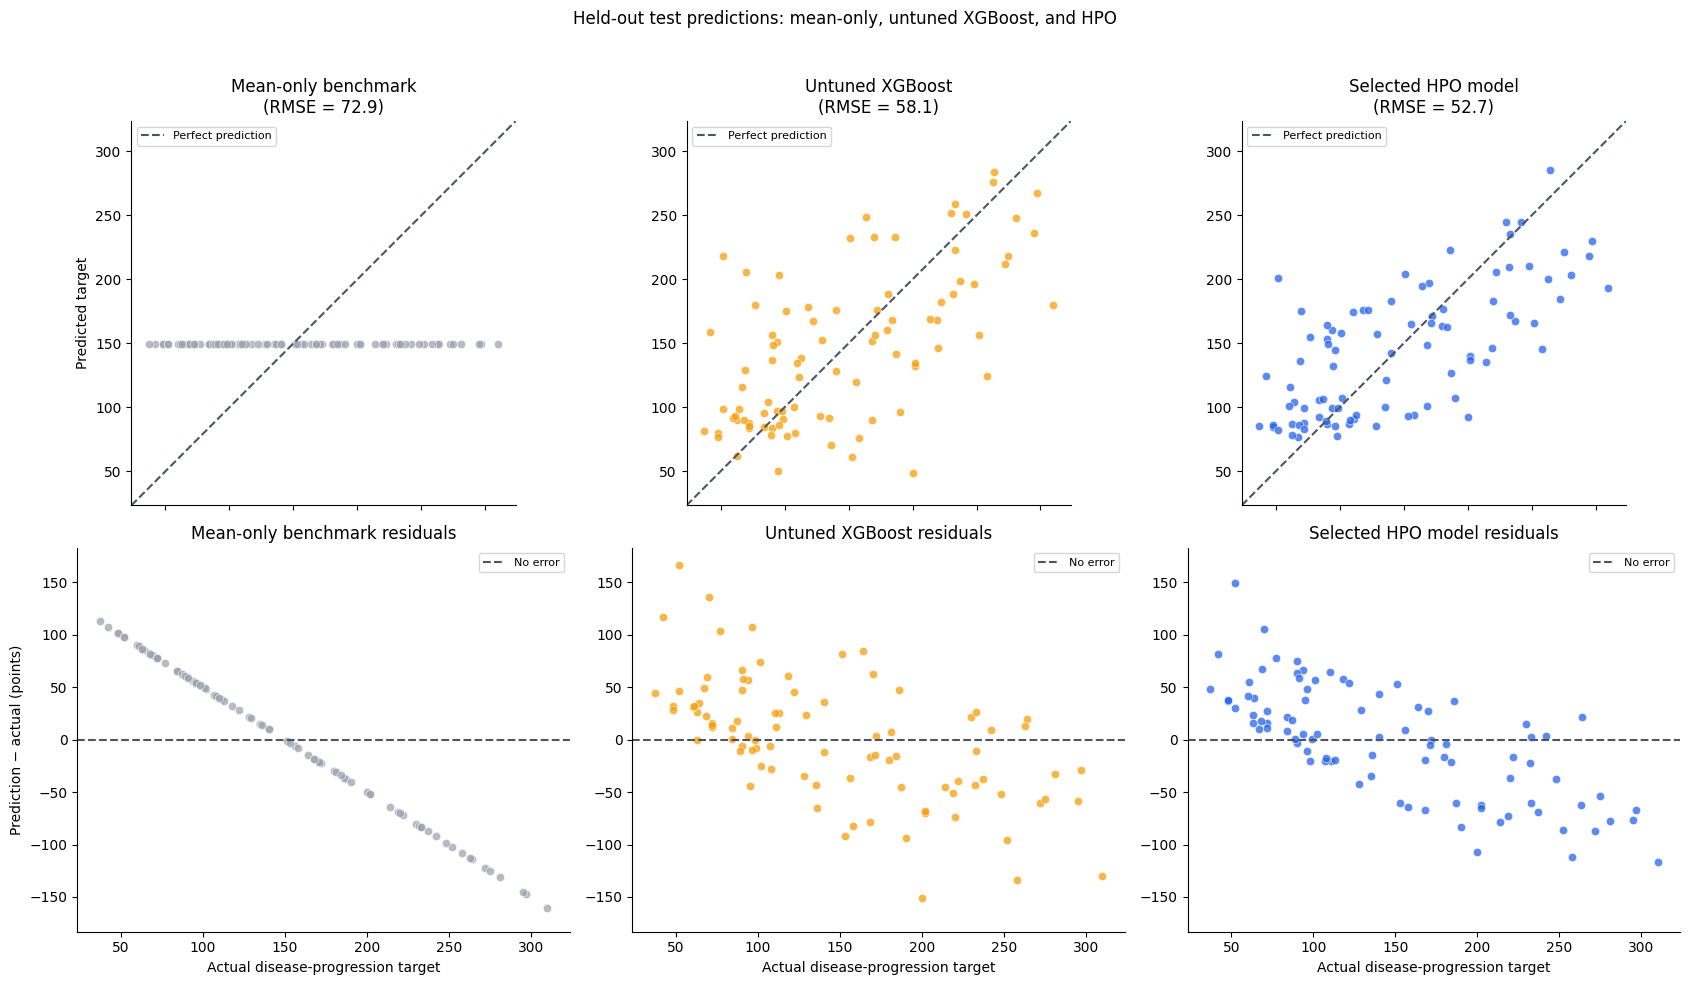

In [41]:
all_predictions = [value for values in prediction_sets.values() for value in values]
plot_min = min(actual_targets.min(), min(all_predictions))
plot_max = max(actual_targets.max(), max(all_predictions))
plot_padding = 0.05 * (plot_max - plot_min)
prediction_limits = [plot_min - plot_padding, plot_max + plot_padding]

residuals_by_model = {
    name: pd.Series(model_predictions) - actual_targets
    for name, model_predictions in prediction_sets.items()
}
residual_limit = max(max(abs(values).max() for values in residuals_by_model.values()), 1) * 1.1

fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharex=True)

def plot_diagnostics(column, model_name, model_predictions):
    colour = model_colours[model_name]
    parity_axis = axes[0, column]
    residual_axis = axes[1, column]

    # Points on the diagonal are perfect; vertical distance from it is prediction error.
    parity_axis.scatter(actual_targets, model_predictions, alpha=0.75, color=colour, edgecolor="white", linewidth=0.5)
    parity_axis.plot(prediction_limits, prediction_limits, "--", color="#4b5563", label="Perfect prediction")
    parity_axis.set(xlim=prediction_limits, ylim=prediction_limits, title=f"{model_name}\n(RMSE = {test_rmse_by_model[model_name]:.1f})")
    parity_axis.set_aspect("equal", adjustable="box")
    parity_axis.legend(fontsize=8)

    residual_axis.scatter(actual_targets, residuals_by_model[model_name], alpha=0.75, color=colour, edgecolor="white", linewidth=0.5)
    residual_axis.axhline(0, linestyle="--", color="#4b5563", label="No error")
    residual_axis.set(xlim=prediction_limits, ylim=(-residual_limit, residual_limit), xlabel="Actual disease-progression target", title=f"{model_name} residuals")
    residual_axis.legend(fontsize=8)

    for axis in (parity_axis, residual_axis):
        axis.spines[["top", "right"]].set_visible(False)

for column, (model_name, model_predictions) in enumerate(prediction_sets.items()):
    plot_diagnostics(column, model_name, model_predictions)

axes[0, 0].set_ylabel("Predicted target")
axes[1, 0].set_ylabel("Prediction − actual (points)")
fig.suptitle("Held-out test predictions: mean-only, untuned XGBoost, and HPO", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 10. What this demo demonstrates

Demo 3 moves beyond consuming a pretrained API: we use managed infrastructure to train and select a regression model. The untuned baseline gives HPO a meaningful reference point, while SageMaker automates the trial infrastructure and comparison. We still decide whether the dataset, target, RMSE metric, search space, and final evaluation are appropriate.

The workflow also separates four distinct outcomes:

- The **baseline training job** shows performance from one fixed, reasonable configuration.
- A **training job** produces a model artefact from one hyperparameter configuration.
- A **tuning job** compares training jobs using validation performance and selects the best candidate.
- A **test evaluation** estimates the selected model's performance on data not used to train or select it.

Finally, training and serving are separate lifecycle stages. A model artefact in S3 is persistent data; an endpoint is live compute that makes the artefact callable and continues to incur cost until deleted.

## 11. Clean up the AWS resources

The endpoint and other managed resources can incur charges. When you have finished, use the shared management script to read the recorded resource names and delete the endpoint, endpoint configuration, model, and CloudFormation role stack. A successful teardown also removes `.demo-state.json`, ready for a fresh run. Add `--delete-s3` and the bucket name if you also want to remove the demo data, model artefacts, and bucket. The `--yes` flag is required because teardown is destructive.

In [ ]:
print("When you have finished the demo, run from the demo/ directory:")
print("./manage_demo.sh --demo 3 --action teardown --yes --profile cits5503")
print("To also remove the S3 data and bucket, add --delete-s3 --bucket YOUR-UNIQUE-BUCKET.")